# Visualising datasets

## 0.1. Imports and load data

In [66]:
import ase.io
import os
from pathlib import Path
import numpy as np
import importlib
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from scipy.linalg import orthogonal_procrustes

from mace import modules
from mace.data.atom_data_loader import AtomDataLoaderBuilder
from mace.testing import Tester, extract_latent_space
from mace.training import FreezeStrategy, NaiveStrategy, Trainer, initialise_autoencoder

import sampling_methods.descriptors as descriptors
import sampling_methods.selectors as selectors
import utils.training as training

importlib.reload(descriptors)
importlib.reload(selectors)
importlib.reload(training)

MAX_EPOCHS = 10
R_MAX = 5.0
BATCH_SIZE = 16
BASE_LR = 1.0e-3
TRANSFER_LR = 5.0e-4
DEVICE = torch.device("cpu")

# define wrapper classes
data_builder = AtomDataLoaderBuilder(
    cutoff=R_MAX, energy_key="REF_energy", forces_key="REF_forces"
)



In [67]:
ROOT_PATH = Path.cwd()
DATA_DIR = ROOT_PATH / "../data"

# dataset for training the base model, ie foundation/pre-trained model
BASE_XYZ = DATA_DIR / "A02_propene_grid_static_2e2o.xyz"
BASE_N_GEOMETRIES = 3731  # number of geometries to use from the base dataset

# dataset for transfer learning
TRANSFER_XYZ = DATA_DIR / "A02_propene_grid_static_4e4o.xyz"
TRANSFER_N_GEOMETRIES = 3731 # number of geometries to use from the transfer dataset

OUTPUT_DIR = ROOT_PATH / "../outputs"

base_atoms_list = ase.io.read(BASE_XYZ, index=f":{BASE_N_GEOMETRIES}")
transfer_atoms_list = ase.io.read(TRANSFER_XYZ, index=f":{TRANSFER_N_GEOMETRIES}")

print("base_atoms_list length:", len(base_atoms_list))
print("transfer_atoms_list length:", len(transfer_atoms_list))


base_atoms_list length: 3731
transfer_atoms_list length: 3731


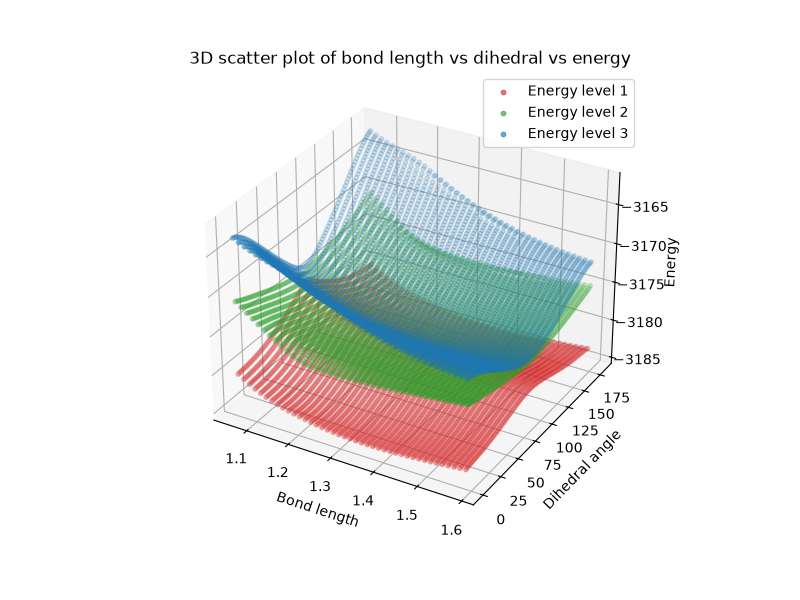

In [ ]:
%matplotlib widget

bond_lengths = []
dihedrals = []
energy_surfaces = None

for atom in base_atoms_list:
    bond_length = descriptors.get_descriptor("bond_lengths", atom)[0]
    dihedral = descriptors.get_descriptor("dihedral", atom)[0]

    bond_lengths.append(bond_length)
    dihedrals.append(dihedral)

    energy = None
    if "REF_energy" in atom.info:
        energy = np.asarray(atom.info["REF_energy"])
    elif "energy" in atom.info:
        energy = np.asarray(atom.info["energy"])
    elif "REF_energy" in atom.arrays:
        energy = np.asarray(atom.arrays["REF_energy"])
    elif "energy" in atom.arrays:
        energy = np.asarray(atom.arrays["energy"])
    else:
        raise KeyError("No energy array found in atom.info or atom.arrays")

    energy = np.asarray(energy).flatten()
    if energy_surfaces is None:
        energy_surfaces = [[] for _ in range(len(energy))]
    elif len(energy) != len(energy_surfaces):
        raise ValueError("Expected the same number of energy levels for each atom")

    for i, e in enumerate(energy):
        energy_surfaces[i].append(e)

bond_lengths = np.asarray(bond_lengths)
dihedrals = np.asarray(dihedrals)
energy_surfaces = [np.asarray(surface) for surface in energy_surfaces]

colors = ["tab:red", "tab:green", "tab:blue", "tab:purple"]
labels = [f"Energy level {i+1}" for i in range(len(energy_surfaces))]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")

for i, energies in enumerate(energy_surfaces):
    ax.scatter(
        bond_lengths,
        dihedrals,
        energies,
        color=colors[i % len(colors)],
        s=10,
        alpha=0.6,
        label=labels[i],
    )

ax.set_xlabel("Bond length")
ax.set_ylabel("Dihedral angle")
ax.set_zlabel("Energy")
ax.set_title("3D scatter plot of bond length vs dihedral vs energy")
ax.legend()
plt.show()

## 0.2. Split into test, train, valid sets

In [68]:
# get bond lengths and dihedrals
# tested on propene only

desc_matrix = []
bond_lengths = []
dihedrals = []

for atom in base_atoms_list:
    bond_length = descriptors.get_descriptor("bond_lengths",atom)[0]
    dihedral = descriptors.get_descriptor("dihedral",atom)[0]
    
    bond_lengths.append(bond_length)
    dihedrals.append(dihedral)
    desc_matrix.append([bond_length, dihedral])

desc_matrix = np.asarray(desc_matrix)

# extract test set
# the same test set is removed from both base and transfer datasets

TEST_SET_FRACTION = 0.1
TEST_SET_SIZE = int(np.floor(int(BASE_N_GEOMETRIES) * TEST_SET_FRACTION))

test_set_idx = selectors.get_selector("uniform_grid", desc_matrix, TEST_SET_SIZE)
base_test_set = [base_atoms_list[i] for i in test_set_idx]
transfer_test_set = [transfer_atoms_list[i] for i in test_set_idx]
print("Test set size:", len(base_test_set))

# remaining geometries are for training and validation
train_valid_set_idx = np.setdiff1d(np.arange(len(transfer_atoms_list)), test_set_idx)
base_train_valid_set = [base_atoms_list[i] for i in train_valid_set_idx]
transfer_train_valid_set = [transfer_atoms_list[i] for i in train_valid_set_idx]

# split remaining geometries into train and valid sets
# the same for both base and transfer datasets

SEED = 42 # set as int to get the same split every time
VALID_SET_FRACTION = 0.1 # as a fraction of the total dataset

train_set_idx, valid_set_idx = train_test_split(
    train_valid_set_idx, test_size=VALID_SET_FRACTION/(1-TEST_SET_FRACTION), random_state=SEED, shuffle=True
)

base_train_set = [base_atoms_list[i] for i in train_set_idx]
print("\nBase train set size:", len(base_train_set))
base_valid_set = [base_atoms_list[i] for i in valid_set_idx]
print("Base valid set size:", len(base_valid_set))

transfer_train_set = [transfer_atoms_list[i] for i in train_set_idx]
print("\nFull high-fidelity train set size:", len(transfer_train_set))
transfer_valid_set = [transfer_atoms_list[i] for i in valid_set_idx]
print("Full high-fidelity valid set size:", len(transfer_valid_set))


Test set size: 361

Base train set size: 2995
Base valid set size: 375

Full high-fidelity train set size: 2995
Full high-fidelity valid set size: 375


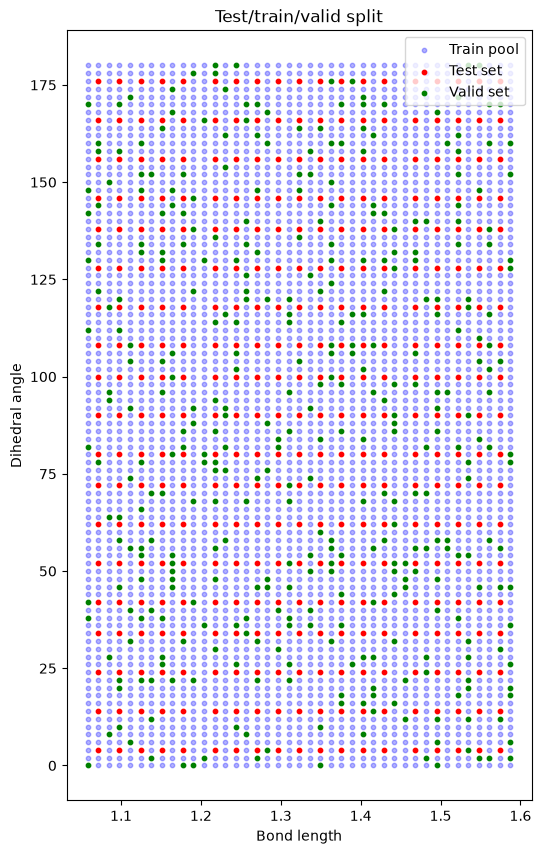

In [14]:
# visualise
%matplotlib inline

plt.figure(figsize=(6, 10))  

plt.scatter([bond_lengths[i] for i in train_set_idx],
            [dihedrals[i] for i in train_set_idx], 
            color='blue', marker='o', s=10, 
            alpha=0.3,
            label='Train pool')

plt.scatter([bond_lengths[i] for i in test_set_idx], 
            [dihedrals[i] for i in test_set_idx], 
            color='red', marker='o', s=10, label='Test set')

plt.scatter([bond_lengths[i] for i in valid_set_idx], 
            [dihedrals[i] for i in valid_set_idx], 
            color='green', marker='o', s=10, label='Valid set')

plt.title("Test/train/valid split")
plt.xlabel("Bond length")
plt.ylabel("Dihedral angle")
plt.legend()

plt.show()

## 0.3. Descriptor

In [69]:
# load base model, full model

base_model_filename = "base_propene_3731_geom_2e2o_50_epoch.pt"
base_model_save_path = OUTPUT_DIR / "base_models" / base_model_filename
base_model = torch.load(base_model_save_path, weights_only=False)

base_model.eval()

base_encoder = base_model.perm_encoder

full_model_filename = "full_propene_3731_geom_4e4o_50_epoch.pt"
full_model_save_path = OUTPUT_DIR / "full_models" / full_model_filename
full_model = torch.load(full_model_save_path, weights_only=False)

full_model.eval()

AutoencoderExcitedMACE(
  (node_embedding): LinearNodeEmbeddingBlock(
    (linear): Linear(2x0e -> 4x0e | 8 weights)
  )
  (radial_embedding): RadialEmbeddingBlock(
    (bessel_fn): BesselBasis(r_max=5.0, num_basis=4, trainable=False)
    (cutoff_fn): PolynomialCutoff(p=3.0, r_max=5.0)
  )
  (perm_encoder): PermutationInvariantEncoder(
    (elementwise_nn): Sequential(
      (0): Linear(in_features=1, out_features=16, bias=True)
      (1): ELU(alpha=1.0)
      (2): Linear(in_features=16, out_features=16, bias=True)
      (3): ELU(alpha=1.0)
      (4): Linear(in_features=16, out_features=16, bias=True)
      (5): ELU(alpha=1.0)
      (6): Linear(in_features=16, out_features=16, bias=True)
      (7): ELU(alpha=1.0)
    )
    (post_aggregation_nn): Sequential(
      (0): Linear(in_features=16, out_features=16, bias=True)
      (1): ELU(alpha=1.0)
      (2): Linear(in_features=16, out_features=16, bias=True)
      (3): ELU(alpha=1.0)
      (4): Linear(in_features=16, out_features=16, bias=

In [102]:
DESCRIPTOR_TYPE = ["bond_lengths", "bond_angles", "dihedral", "energies", "encoded_energies", "soap", "acsf", "mbtr", "latent_space"]
DESCRIPTOR = DESCRIPTOR_TYPE[7]  # choose the descriptor type to use

# matrix of descriptors for each geometry
# sampling is done on base dataset, out of the training pool only
# ie test and valid sets are already removed
desc_matrix = []
if DESCRIPTOR == "latent_space":
    base_train_loader_unshuffle = data_builder.load(
        base_train_set, batch_size=BATCH_SIZE, shuffle=False
    )
    train_latent_space = extract_latent_space(
        base_model, base_train_loader_unshuffle, device=DEVICE
    )
    desc_matrix = train_latent_space
else:
    for atom in base_train_set:
        desc_matrix.append(descriptors.get_descriptor(DESCRIPTOR,atom,base_encoder))
    desc_matrix = np.asarray(desc_matrix)

# n*m, where n is the number of geometries and m is the dimension of the descriptor
# eg if we use bond_lengths and propene, m=2 because there's 2 CC bonds in propene
print("desc_matrix shape:", desc_matrix.shape)
print("desc_matrix unique shape:", np.unique(desc_matrix, axis=0).shape)
print("desc_matrix:\n", desc_matrix)


/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/site-packages/dscribe/core/system.py:96: FutureWarning: Please use atoms.calc
  calculator=atoms.get_calculator(),


desc_matrix shape: (2995, 765)
desc_matrix unique shape: (2995, 765)
desc_matrix:
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [61]:
# get desc vectors for the test and valid sets as well

test_desc_matrix = []
valid_desc_matrix = []

if DESCRIPTOR == "latent_space":
    base_test_loader_unshuffle = data_builder.load(
        base_test_set, batch_size=BATCH_SIZE, shuffle=False
    )
    test_latent_space = extract_latent_space(
        base_model, base_test_loader_unshuffle, device=DEVICE
    )
    test_desc_matrix = test_latent_space

    base_valid_loader_unshuffle = data_builder.load(
        base_valid_set, batch_size=BATCH_SIZE, shuffle=False
    )
    valid_latent_space = extract_latent_space(
        base_model, base_valid_loader_unshuffle, device=DEVICE
    )
    valid_desc_matrix = valid_latent_space
else:
    for atom in base_test_set:
        test_desc_matrix.append(descriptors.get_descriptor(DESCRIPTOR,atom,base_encoder))
    test_desc_matrix = np.asarray(test_desc_matrix)

    for atom in base_valid_set:
        valid_desc_matrix.append(descriptors.get_descriptor(DESCRIPTOR,atom,base_encoder))
    valid_desc_matrix = np.asarray(valid_desc_matrix)

print("test_desc_matrix shape:", test_desc_matrix.shape)
print("test_desc_matrix unique shape:", np.unique(test_desc_matrix, axis=0).shape)
print("test_desc_matrix:\n", test_desc_matrix)

print("\nvalid_desc_matrix shape:", valid_desc_matrix.shape)
print("valid_desc_matrix unique shape:", np.unique(valid_desc_matrix, axis=0).shape)
print("valid_desc_matrix:\n", valid_desc_matrix)

test_desc_matrix shape: (361, 16)
test_desc_matrix unique shape: (361, 16)
test_desc_matrix:
 [[-1.1955875   0.37429562 -0.68092173 ... -1.1248734   2.0064528
   0.71666646]
 [-1.1977904   0.37588707 -0.682504   ... -1.1230462   2.0052843
   0.71415216]
 [-1.2022622   0.37914622 -0.6857292  ... -1.1193557   2.0028791
   0.7090083 ]
 ...
 [-1.2149435   0.11322843 -0.5595102  ... -1.3224487   1.7820091
   0.9029384 ]
 [-1.2139695   0.11239144 -0.55874586 ... -1.3231355   1.7825608
   0.9041743 ]
 [-1.2134229   0.11192884 -0.55832046 ... -1.323524    1.7828687
   0.90486103]]

valid_desc_matrix shape: (375, 16)
valid_desc_matrix unique shape: (375, 16)
valid_desc_matrix:
 [[-1.2011967   0.1207682  -0.55807394 ... -1.335286    1.7878163
   0.90115565]
 [-1.2017751   0.39725173 -0.69450694 ... -1.1021404   2.0215664
   0.6968576 ]
 [-1.1874938   0.12371135 -0.55448246 ... -1.3412611   1.7993425
   0.90524936]
 ...
 [-1.1825999   0.15418749 -0.5676137  ... -1.3241768   1.82133
   0.8827539 ]

In [62]:
# get desc vectors for the full (high-fidelity) dataset as well

full_desc_matrix = []
if DESCRIPTOR == "latent_space":
    full_train_loader_unshuffle = data_builder.load(
        transfer_train_set, batch_size=BATCH_SIZE, shuffle=False
    )
    full_latent_space = extract_latent_space(
        full_model, full_train_loader_unshuffle, device=DEVICE
    )
    full_desc_matrix = full_latent_space

else:
    for atom in transfer_train_set:
        full_desc_matrix.append(descriptors.get_descriptor(DESCRIPTOR,atom,base_encoder))
    full_desc_matrix = np.asarray(full_desc_matrix)

print("full_desc_matrix shape:", full_desc_matrix.shape)
print("full_desc_matrix unique shape:", np.unique(full_desc_matrix, axis=0).shape)
print("full_desc_matrix:\n", full_desc_matrix)

full_desc_matrix shape: (2995, 16)
full_desc_matrix unique shape: (2995, 16)
full_desc_matrix:
 [[-1.3279651   0.07724133 -0.54707545 ... -1.1445769   1.3535807
   0.8615856 ]
 [-1.3107799   0.1294455  -0.56737036 ... -1.1594243   1.3660119
   0.81733894]
 [-1.3513125   0.24077891 -0.63761187 ... -1.1106573   1.3811455
   0.70203614]
 ...
 [-1.3051718   0.10645837 -0.5538208  ... -1.1650164   1.3656855
   0.84167886]
 [-1.32845     0.16730025 -0.5926375  ... -1.1427999   1.3619604
   0.7735697 ]
 [-1.3133224   0.07793178 -0.5423068  ... -1.1596975   1.3557528
   0.86483234]]


## 0.4. Selector

In [103]:
SELECTOR_TYPE = ["random_sampling", "farthest_point_sampling", "k_means_clustering", "k_means_clustering_weighted", "birch", "birch_weighted", "dbscan", "dbscan_weighted"]
SELECTOR = SELECTOR_TYPE[2]  # choose the selector type to use

# number of samples to select from the transfer dataset
N_SAMPLES = 100

# select samples based on the descriptor matrix
sampled_idx = selectors.get_selector(SELECTOR, desc_matrix, N_SAMPLES, n_clusters=5)

# sample atoms out of transfer dataset
sampled_atoms = [transfer_train_set[i] for i in sampled_idx]

print("sampled indices:\n", sampled_idx)
print("number sampled:", len(sampled_idx))

n clusters: 5
sampled indices:
 [1918  774  612  133 2164  733 2193 1309 2779 2213 1436 2049 2882 2565
  641 1604 2435 1680  701  838 1276  311  482  812 1457 1716 2388 2691
 2657  977 1808 1358 1884  164 2634 2560 2550 2488 2302 1439 2207 1232
  332  527  603 1072 2712 1203  455  662 2620  708 2677 1778 1479  773
 1366 2365 1783 1357 1992 1607 2370 2792 1260 2602  932  580  126 2949
  951 2160 2690 1048  315 2601  636 1421 2761 1838 2857 1558 1930 1471
  601 2499  931 2969 2641 2623  797 1677 1963 1395  170  719  502  762
  268 2705]
number sampled: 100


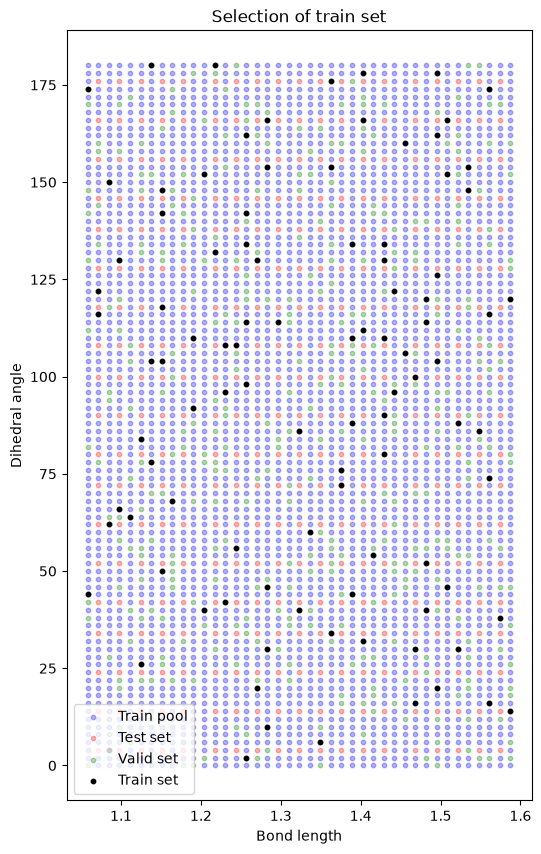

In [81]:
# visualise
%matplotlib inline

plt.figure(figsize=(6, 10))  

plt.scatter([bond_lengths[i] for i in train_set_idx],
            [dihedrals[i] for i in train_set_idx], 
            color='blue', marker='o', s=10, 
            alpha=0.3,
            label='Train pool')

plt.scatter([bond_lengths[i] for i in test_set_idx], 
            [dihedrals[i] for i in test_set_idx], 
            color='red', marker='o', s=10, 
            alpha=0.3,
            label='Test set')

plt.scatter([bond_lengths[i] for i in valid_set_idx], 
            [dihedrals[i] for i in valid_set_idx], 
            color='green', marker='o', s=10, 
            alpha=0.3,
            label='Valid set')

plt.scatter([bond_lengths[i] for i in sampled_idx], 
            [dihedrals[i] for i in sampled_idx], 
            color='black', marker='o', s=10, 
            alpha=1,
            label='Train set')

plt.title("Selection of train set")
plt.xlabel("Bond length")
plt.ylabel("Dihedral angle")
plt.legend()

plt.show()

## 1. PCA plot of selection

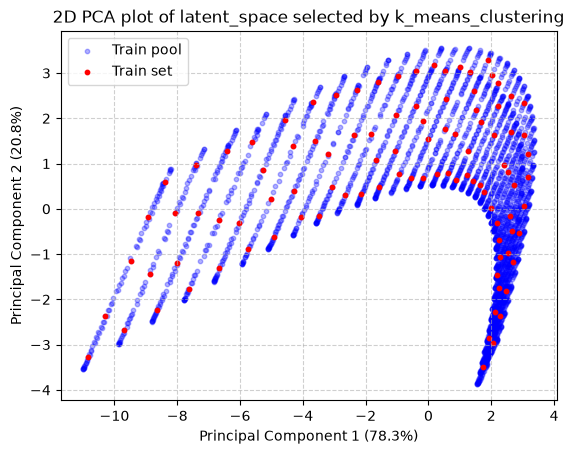

In [82]:
# 2D PCA
%matplotlib inline

scaler = StandardScaler()
desc_matrix_scaled = scaler.fit_transform(desc_matrix)
test_desc_matrix_scaled = scaler.transform(test_desc_matrix)
valid_desc_matrix_scaled = scaler.transform(valid_desc_matrix)

pca_2d = PCA(n_components=2)
desc_matrix_pca_2d = pca_2d.fit_transform(desc_matrix_scaled)
test_desc_matrix_pca_2d = pca_2d.transform(test_desc_matrix_scaled)
valid_desc_matrix_pca_2d = pca_2d.transform(valid_desc_matrix_scaled)

plt.scatter(desc_matrix_pca_2d[:,0], desc_matrix_pca_2d[:,1], color='blue', marker='o', alpha=0.3, s=10, label='Train pool')
plt.scatter(
    desc_matrix_pca_2d[sampled_idx, 0],
    desc_matrix_pca_2d[sampled_idx, 1],
    color='red',
    marker='o',
    alpha=1,
    s=10,
    label='Train set'
)
# plt.scatter(test_desc_matrix_pca_2d[:,0], test_desc_matrix_pca_2d[:,1], color='red', marker='o', alpha=0.3, s=10, label='Test set')
# plt.scatter(valid_desc_matrix_pca_2d[:,0], valid_desc_matrix_pca_2d[:,1], color='green', marker='o', alpha=0.3, s=10, label='Valid set')

plt.title(f'2D PCA plot of {DESCRIPTOR} selected by {SELECTOR}')
plt.xlabel(f"Principal Component 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Principal Component 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.show()


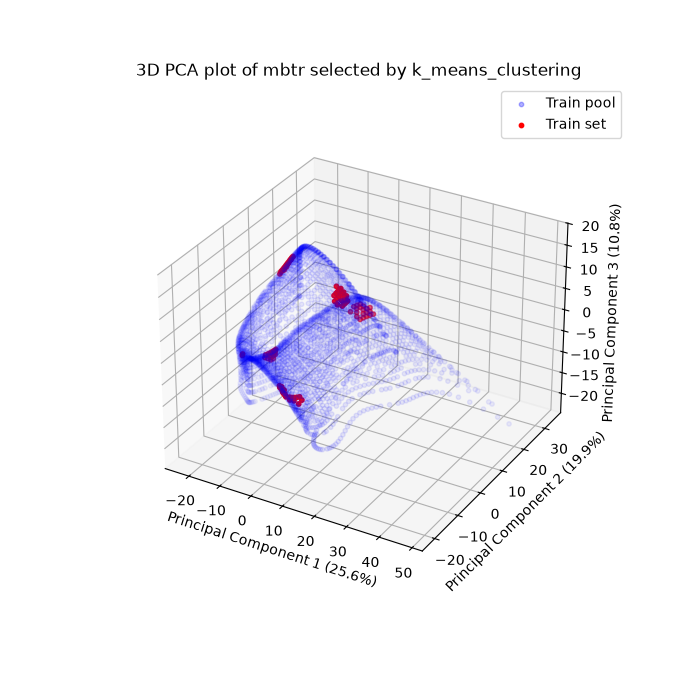

In [ ]:
# 3D PCA
%matplotlib widget

scaler = StandardScaler()
desc_matrix_scaled = scaler.fit_transform(desc_matrix)
# test_desc_matrix_scaled = scaler.transform(test_desc_matrix)
# valid_desc_matrix_scaled = scaler.transform(valid_desc_matrix)

pca_3d = PCA(n_components=3)
desc_matrix_pca_3d = pca_3d.fit_transform(desc_matrix_scaled)
# test_desc_matrix_pca_3d = pca_3d.transform(test_desc_matrix_scaled)
# valid_desc_matrix_pca_3d = pca_3d.transform(valid_desc_matrix_scaled)

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(projection='3d')
ax.set_box_aspect(None, zoom=0.85)

ax.scatter(desc_matrix_pca_3d[:,0], desc_matrix_pca_3d[:,1], desc_matrix_pca_3d[:,2], color='blue', marker='o', alpha=0.3, s=10, label="Train pool")
ax.scatter(
    desc_matrix_pca_3d[sampled_idx, 0],
    desc_matrix_pca_3d[sampled_idx, 1],
    desc_matrix_pca_3d[sampled_idx, 2],
    color='red',
    marker='o',
    alpha=1,
    s=10,
    label='Train set'
)
# ax.scatter(test_desc_matrix_pca_3d[:,0], test_desc_matrix_pca_3d[:,1], test_desc_matrix_pca_3d[:,2], color='red', marker='o', alpha=0.3, s=10, label='Test set')
# ax.scatter(valid_desc_matrix_pca_3d[:,0], valid_desc_matrix_pca_3d[:,1], valid_desc_matrix_pca_3d[:,2], color='green', marker='o', alpha=0.3, s=10, label='Valid set')

plt.title(f'3D PCA plot of {DESCRIPTOR} selected by {SELECTOR}')
ax.set_xlabel(f"Principal Component 1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"Principal Component 2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_zlabel(f"Principal Component 3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.show()


## 3. PCA plot of high-fidelity vs low-fidelity data

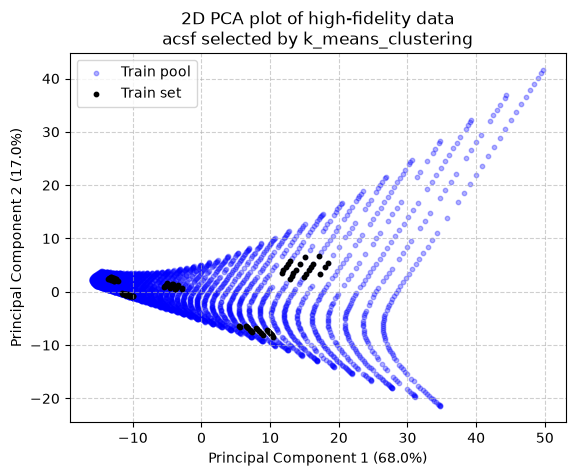

In [47]:
# 2D PCA of high-fidelity (transfer) data
%matplotlib inline

scaler = StandardScaler()
full_desc_matrix_scaled = scaler.fit_transform(full_desc_matrix)

full_desc_matrix_pca_2d = pca_2d.fit_transform(full_desc_matrix_scaled)

plt.scatter(full_desc_matrix_pca_2d[:,0], full_desc_matrix_pca_2d[:,1], color='blue', marker='o', alpha=0.3, s=10, label='Train pool')
plt.scatter(
    full_desc_matrix_pca_2d[sampled_idx, 0],
    full_desc_matrix_pca_2d[sampled_idx, 1],
    color='black',
    marker='o',
    alpha=1,
    s=10,
    label='Train set'
)

plt.title(f'2D PCA plot of high-fidelity data\n{DESCRIPTOR} selected by {SELECTOR}')
plt.xlabel(f"Principal Component 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Principal Component 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.show()


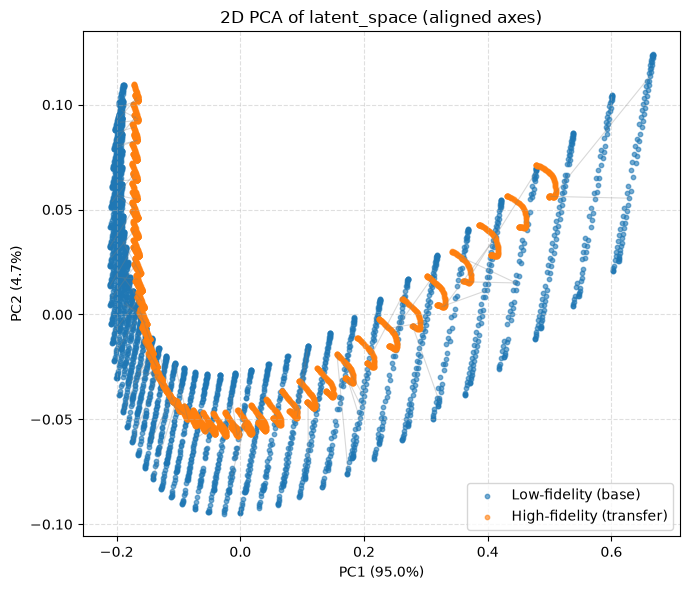

In [64]:
# 2D plot of low-fidelity vs high-fidelity 
%matplotlib inline

# Center both descriptor sets first.
desc_mean = desc_matrix.mean(axis=0, keepdims=True)
desc_centered = desc_matrix - desc_mean
full_centered = full_desc_matrix - full_desc_matrix.mean(axis=0, keepdims=True)

# Rotate/reflect the centered high-fidelity data toward the centered low-fidelity data.
rotation, _ = orthogonal_procrustes(full_centered, desc_centered)
desc_aligned = desc_matrix.copy()
full_aligned = full_centered @ rotation + desc_mean

# Stack the aligned datasets and fit PCA on the combined set.
combined = np.vstack([desc_aligned, full_aligned])

pca_2d = PCA(n_components=2)
pca_2d.fit(combined)

desc_pca_2d = pca_2d.transform(desc_aligned)
full_pca_2d = pca_2d.transform(full_aligned)

plt.figure(figsize=(7, 6))

plt.scatter(
    desc_pca_2d[:, 0],
    desc_pca_2d[:, 1],
    color="tab:blue",
    s=10,
    alpha=0.6,
    label="Low-fidelity (base)",
)

plt.scatter(
    full_pca_2d[:, 0],
    full_pca_2d[:, 1],
    color="tab:orange",
    s=10,
    alpha=0.6,
    label="High-fidelity (transfer)",
)

# Draw one connecting line for every 50 points to keep the plot readable.
n_points = min(len(desc_pca_2d), len(full_pca_2d))
for i in range(0, n_points, 50):
    plt.plot(
        [desc_pca_2d[i, 0], full_pca_2d[i, 0]],
        [desc_pca_2d[i, 1], full_pca_2d[i, 1]],
        color="gray",
        alpha=0.3,
        linewidth=0.8,
    )

plt.title(f"2D PCA of {DESCRIPTOR} (aligned axes)")
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}%)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


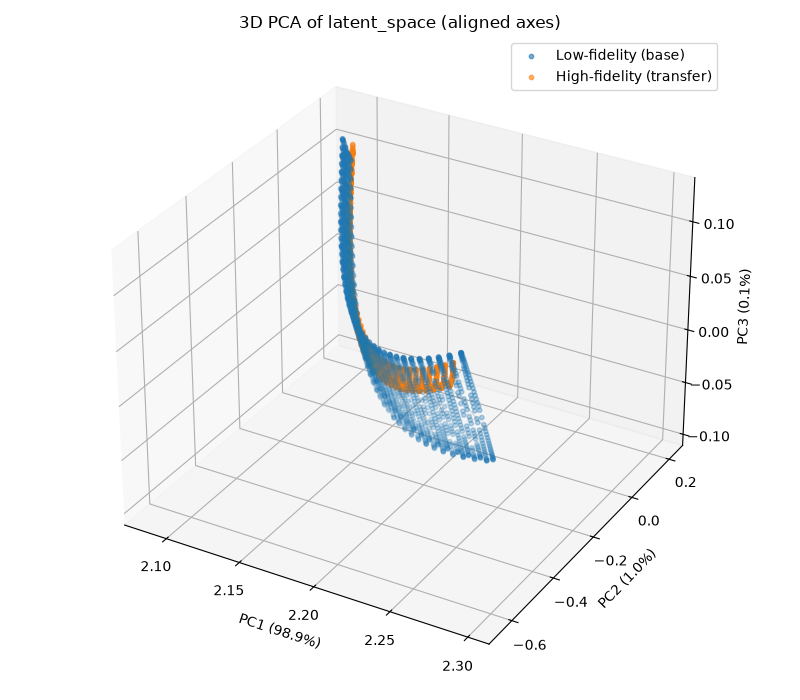

In [65]:
# 3D plot of low-fidelity vs high-fidelity 
%matplotlib widget

desc_mean = desc_matrix.mean(axis=0, keepdims=True)
desc_centered = desc_matrix - desc_mean
full_centered = full_desc_matrix - full_desc_matrix.mean(axis=0, keepdims=True)

rotation, _ = orthogonal_procrustes(full_centered, desc_centered)
desc_aligned = desc_matrix.copy()
full_aligned = full_centered @ rotation + desc_mean

combined = np.vstack([desc_centered, full_aligned])

pca_3d = PCA(n_components=3)
pca_3d.fit_transform(combined)

desc_pca_3d = pca_3d.transform(desc_aligned)
full_pca_3d = pca_3d.transform(full_aligned)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    desc_pca_3d[:, 0],
    desc_pca_3d[:, 1],
    desc_pca_3d[:, 2],
    color="tab:blue",
    s=10,
    alpha=0.6,
    label="Low-fidelity (base)",
)

ax.scatter(
    full_pca_3d[:, 0],
    full_pca_3d[:, 1],
    full_pca_3d[:, 2],
    color="tab:orange",
    s=10,
    alpha=0.6,
    label="High-fidelity (transfer)",
)

n_points = min(len(desc_pca_3d), len(full_pca_3d))
for i in range(0, n_points, 50):
    ax.plot(
        [desc_pca_3d[i, 0], full_pca_3d[i, 0]],
        [desc_pca_3d[i, 1], full_pca_3d[i, 1]],
        [desc_pca_3d[i, 2], full_pca_3d[i, 2]],
        color="gray",
        alpha=0.3,
        linewidth=0.8,
    )

ax.set_title(f"3D PCA of {DESCRIPTOR} (aligned axes)")
ax.set_xlabel(f"PC1 ({pca_3d.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_3d.explained_variance_ratio_[1] * 100:.1f}%)")
ax.set_zlabel(f"PC3 ({pca_3d.explained_variance_ratio_[2] * 100:.1f}%)")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()


## 2. Distances between points

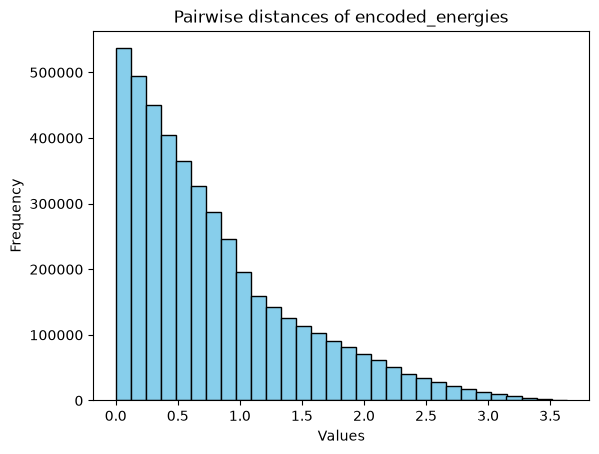

In [15]:
# Pairwise distances
%matplotlib inline

distances = pdist(desc_matrix)

plt.hist(distances, bins=30, color='skyblue', edgecolor='black')

plt.title(f'Pairwise distances of {DESCRIPTOR}')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.show()

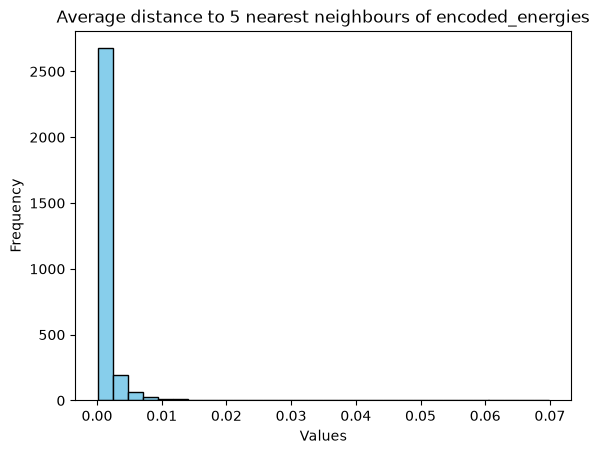

In [16]:
# Average distance to n nearest neighbours

N_NEIGHBORS = 5

nbrs = NearestNeighbors(n_neighbors=N_NEIGHBORS).fit(desc_matrix)
distances, _ = nbrs.kneighbors(desc_matrix)

avg_distances = distances.mean(axis=1)

plt.hist(avg_distances, bins=30, color='skyblue', edgecolor='black')

plt.title(f'Average distance to {N_NEIGHBORS} nearest neighbours of {DESCRIPTOR}')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.show()

## 3. Density

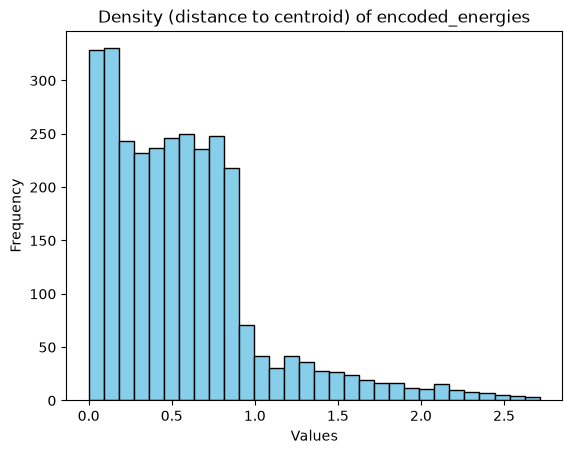

In [17]:
# Distances of all points to centroid

center = desc_matrix.mean(axis=0)
distances = np.linalg.norm(desc_matrix - center, axis=1)

plt.hist(distances, bins=30, color='skyblue', edgecolor='black')

plt.title(f'Density (distance to centroid) of {DESCRIPTOR}')
plt.xlabel('Values')
plt.ylabel('Frequency')

plt.show()


## 4. View molecules

In [11]:
from ase.visualize import view
view(base_atoms_list)

<Popen: returncode: None args: ['/home/lim_yt/micromamba/envs/xmace311/bin/p...>